# CeO2 whole-PDF training: `q0.3-20`

Fixed range: `QMIN = 0.3`, `QMAX = 20`. Generated from `3A-train-model-ceo2_qrange.ipynb`. This notebook uses all 10,000 clusters with deterministic stratified 80/10/10 splits and independently tunes this Q range.


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner import RandomSearch, Hyperband
from keras_tuner.engine.hyperparameters import HyperParameters
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import math

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

# Python 3.7 compatibility for keras_tuner (uses math.prod)
if not hasattr(math, "prod"):
    def _prod(values):
        result = 1
        for value in values:
            result *= int(value)
        return result

    math.prod = _prod

2026-09-04 14:27:04.122004: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-04 14:27:04.411519: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-04 14:27:04.417449: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /workspace/home/.local/opt/tmux/usr

In [2]:
# Import path configuration
import sys
import importlib
from pathlib import Path

PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / 'config.py').is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.py from the current working directory")
sys.path.insert(0, str(PROJECT_ROOT))

import config
importlib.reload(config)
from config import get_path, qrange_paths, qrange_tag, QRANGE_PAIRS

# --- qrange-study: choose the (qmin, qmax) pair to train on -----------------
PAIR_INDEX = 3  # index at generation time; QMIN/QMAX below are fixed
QMIN, QMAX = (0.3, 20.0)
TAG = qrange_tag(QMIN, QMAX)
_qrange = qrange_paths(QMIN, QMAX)
print(f"qrange-study: training CeO2 model for (qmin={QMIN}, qmax={QMAX})  [{TAG}]")

ceo2_pdfs_dir = _qrange['ceo2_calculated_pdfs']
models_dir = _qrange['models'] / 'ceo2_clusters'
results_dir = _qrange['results'] / 'ceo2_clusters'
figures_dir = results_dir / 'figures'
for output_dir in (models_dir, results_dir, figures_dir):
    output_dir.mkdir(parents=True, exist_ok=True)

qrange-study: training CeO2 model for (qmin=0.3, qmax=20.0)  [q0.3-20]


In [3]:
# Read every valid PDF in stable filename order for comparable splits across q ranges
print(f"Reading PDFs from: {ceo2_pdfs_dir}")
files_calc = sorted(
    (
        path
        for path in ceo2_pdfs_dir.glob('*.dat')
        if path.name and path.name[0] in '123456789'
    ),
    key=lambda path: path.name,
)

expected_pdf_count = 10_000
if len(files_calc) != expected_pdf_count:
    raise RuntimeError(
        f"Expected {expected_pdf_count} valid CeO2 PDFs for {TAG}, found {len(files_calc)}"
    )
if len({path.name for path in files_calc}) != len(files_calc):
    raise RuntimeError(f"Duplicate CeO2 PDF filenames found for {TAG}")

print(f"Found all {len(files_calc)} PDF files")

Reading PDFs from: /workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs_q0.3-20
Found all 10000 PDF files


Counts of clusters by nuclearity: {'1': 1860, '2': 2395, '3': 1861, '4': 1326, '5': 1006, '6': 737, '7': 440, '8': 260, '9': 115}
Total number of clusters used: 10000


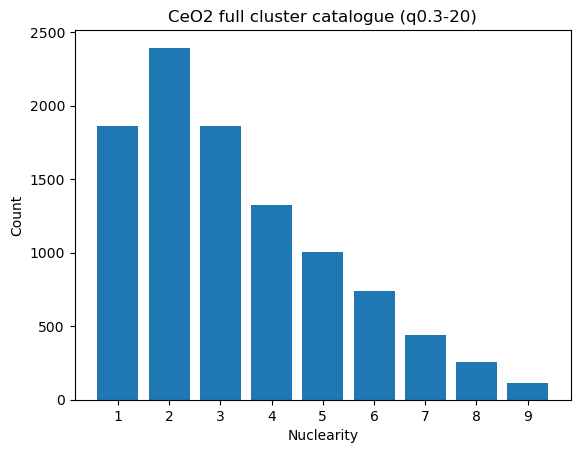

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

# Report the complete, unsliced cluster catalogue
counts = Counter(path.name[0] for path in files_calc)
sorted_counts = {str(nuclearity): counts.get(str(nuclearity), 0) for nuclearity in range(1, 10)}
print('Counts of clusters by nuclearity:', sorted_counts)
print('Total number of clusters used:', len(files_calc))

plt.bar(list(sorted_counts), list(sorted_counts.values()))
plt.xlabel('Nuclearity')
plt.ylabel('Count')
plt.title(f'CeO2 full cluster catalogue ({TAG})')
plt.show()

In [5]:
# Load whole-PDF vectors and derive aligned labels directly from filenames
raw_data_points = []
labels = []
failed_files = []

for index, file_path in enumerate(files_calc, start=1):
    try:
        frame = pd.read_csv(
            file_path,
            usecols=[1],
            skiprows=201,
            header=None,
            sep=r'\s+',
            skipfooter=800,
            engine='python',
        )
        pdf_values = frame.iloc[:, 0].to_numpy()
        if pdf_values.size != 1000:
            raise ValueError(f"expected 1000 PDF points, found {pdf_values.size}")
        raw_data_points.append(pdf_values)
        labels.append(int(file_path.name[0]))
    except Exception as error:
        failed_files.append((file_path.name, str(error)))

    if index == 1 or index % 1000 == 0:
        print(f"Loaded {index} PDFs...")

if failed_files:
    preview = '\n'.join(f"  {name}: {error}" for name, error in failed_files[:10])
    raise RuntimeError(f"Failed to load {len(failed_files)} PDF file(s):\n{preview}")

raw_data_points = np.stack(raw_data_points)
labels = np.asarray(labels, dtype=int)
print(f"Whole-PDF matrix: {raw_data_points.shape}")
print(f"Label distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

Loaded 1 PDFs...
Loaded 1000 PDFs...
Loaded 2000 PDFs...
Loaded 3000 PDFs...
Loaded 4000 PDFs...
Loaded 5000 PDFs...
Loaded 6000 PDFs...
Loaded 7000 PDFs...
Loaded 8000 PDFs...
Loaded 9000 PDFs...
Loaded 10000 PDFs...
Whole-PDF matrix: (10000, 1000)
Label distribution: {1: 1860, 2: 2395, 3: 1861, 4: 1326, 5: 1006, 6: 737, 7: 440, 8: 260, 9: 115}


1


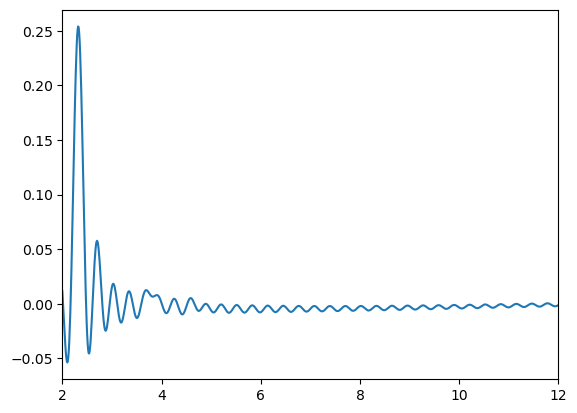

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[113,:]))/100+2, data_points[113,:])
print(labels[113])

In [7]:
# Deterministic stratified 80/10/10 train/test/validation split
X_train, X_temp, y_train, y_temp = train_test_split(
    data_points,
    labels,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=labels,
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=y_temp,
)

for split_name, split_labels in (
    ('train', y_train),
    ('test', y_test),
    ('validation', y_val),
):
    values, split_counts = np.unique(split_labels, return_counts=True)
    print(split_name, len(split_labels), dict(zip(values, split_counts)))

train 8000 {1: 1488, 2: 1916, 3: 1489, 4: 1061, 5: 805, 6: 589, 7: 352, 8: 208, 9: 92}
test 1000 {1: 186, 2: 239, 3: 186, 4: 133, 5: 100, 6: 74, 7: 44, 8: 26, 9: 12}
validation 1000 {1: 186, 2: 240, 3: 186, 4: 132, 5: 101, 6: 74, 7: 44, 8: 26, 9: 11}


Hyperparameter tuning

In [8]:
def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [64, 128, 256]),
                     activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64]),
                     activation='relu'))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [64, 128, 256]), activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [9]:
# Tune this q range independently in its namespaced model directory
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    directory=str(models_dir),
    project_name=f'hyperband_ceo2_2-12_{TAG}',
    seed=RANDOM_SEED,
    overwrite=True,
)

tuner.search(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3)],
)

Trial 90 Complete [00h 04m 34s]
val_accuracy: 0.4259999990463257

Best val_accuracy So Far: 0.9990000128746033
Total elapsed time: 03h 06m 12s


In [10]:
tuner.search_space_summary()
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best hyperparameters:')
print(best_hyperparameters.values)

# Extract best hyperparameters for retraining
best_filters1 = best_hyperparameters.get('filters1')
best_kernel_size1 = best_hyperparameters.get('kernel_size1')
best_filters2 = best_hyperparameters.get('filters2')
best_kernel_size2 = best_hyperparameters.get('kernel_size2')
best_dropout = best_hyperparameters.get('dropout')
best_dense_units = best_hyperparameters.get('dense_units')
best_learning_rate = best_hyperparameters.get('learning_rate')

print('\nExtracted hyperparameters for retraining:')
print(f'  filters1: {best_filters1}, kernel_size1: {best_kernel_size1}')
print(f'  filters2: {best_filters2}, kernel_size2: {best_kernel_size2}')
print(f'  dropout: {best_dropout}, dense_units: {best_dense_units}')
print(f'  learning_rate: {best_learning_rate}')

best_model = tuner.get_best_models(num_models=1)[0]

# Save the best all-cluster model to the q-range namespace
best_model_path = models_dir / f'tuned_ceo2_calc_2-12_{TAG}.h5'
best_model.save(best_model_path)
print(f'\nBest model saved to: {best_model_path}')

Search space summary
Default search space size: 7
filters1 (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
kernel_size1 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
filters2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.1, 'step': None, 'sampling': 'log'}
Best hyperparameters:
{'filters1': 32, 'kernel_size1': 256, 'dropout': 0.2, 'filters2': 32, 'kernel_size2': 64, 'dense_units': 256, 'learning_rate': 0.00023593138455410534, 'tuner/epochs': 30, 'tuner/initial_epoch': 1

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 745, 32)           8224      
                                                                 
 batch_normalization_1 (Batc  (None, 745, 32)          128       
 hNormalization)                                                 
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 372, 32)          0         
 1D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 372, 32)           0         
                                                                 
 conv1d_3 (Conv1D)           (None, 309, 32)           65568     
                                                                 
 dropout_4 (Dropout)         (None, 309, 32)          

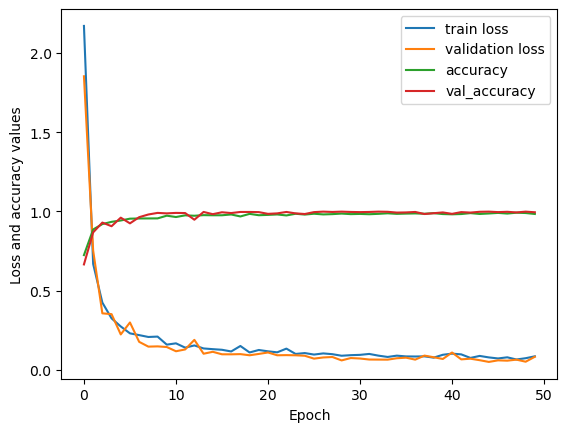

In [11]:
# Retrain the selected architecture reproducibly on all training clusters
num_epochs = 50
keras.utils.set_random_seed(RANDOM_SEED)

model = Sequential()
model.add(Conv1D(filters=best_filters1, kernel_size=best_kernel_size1, activation='relu', input_shape=(1000, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(best_dropout))
model.add(Conv1D(filters=best_filters2, kernel_size=best_kernel_size2, activation='relu'))
model.add(Dropout(best_dropout))
model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
model.add(Flatten())
model.add(Dense(units=best_dense_units, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
model.add(Dropout(best_dropout))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))

optimizer = Adam(learning_rate=best_learning_rate)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

retrain_model_path = models_dir / f'tuned_ceo2_calc_2-12_retrain_{TAG}.h5'
checkpoint = ModelCheckpoint(
    str(retrain_model_path),
    monitor='val_accuracy',
    mode='max',
    verbose=1,
    save_best_only=True,
)

seqModel = model.fit(
    X_train,
    y_train,
    epochs=num_epochs,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint],
)
test_loss, test_acc = model.evaluate(X_val, y_val)
print('Validation accuracy:', test_acc)
print(seqModel.history.keys())
print(f'Retrained model saved to: {retrain_model_path}')

xc = range(num_epochs)
plt.plot(xc, seqModel.history['loss'], label='train loss')
plt.plot(xc, seqModel.history['val_loss'], label='validation loss')
plt.plot(xc, seqModel.history['accuracy'], label='accuracy')
plt.plot(xc, seqModel.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss and accuracy values')
plt.legend()

In [12]:
# Evaluate on test set
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model(retrain_model_path)

load_model.evaluate(X_test, y_test)
y_pred_prob = load_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

32/32 [==============================] - 0s 8ms/step
Confusion matrix [[186   0   0   0   0   0   0   0   0]
 [  0 239   0   0   0   0   0   0   0]
 [  0   0 186   0   0   0   0   0   0]
 [  0   0   0 133   0   0   0   0   0]
 [  0   0   0   0 100   0   0   0   0]
 [  0   0   0   0   1  73   0   0   0]
 [  0   0   0   0   0   0  44   0   0]
 [  0   0   0   0   0   0   1  25   0]
 [  0   0   0   0   0   0   0   0  12]]
Recall score: [1.         1.         1.         1.         1.         0.98648649
 1.         0.96153846 1.        ]
F1 score: [1.         1.         1.         1.         0.99502488 0.99319728
 0.98876404 0.98039216 1.        ]
Precision score: [1.         1.         1.         1.         0.99009901 1.
 0.97777778 1.         1.        ]


Confusion matrix, without normalization
[[186   0   0   0   0   0   0   0   0]
 [  0 239   0   0   0   0   0   0   0]
 [  0   0 186   0   0   0   0   0   0]
 [  0   0   0 133   0   0   0   0   0]
 [  0   0   0   0 100   0   0   0   0]
 [  0   0   0   0   1  73   0   0   0]
 [  0   0   0   0   0   0  44   0   0]
 [  0   0   0   0   0   0   1  25   0]
 [  0   0   0   0   0   0   0   0  12]]


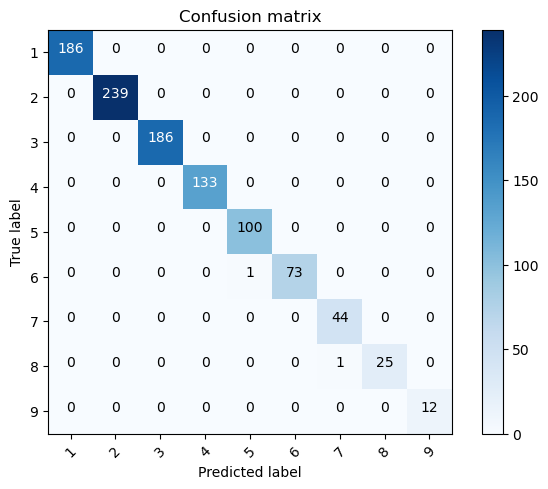

In [13]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_test), title='Confusion matrix', normalize=False)
plt.show()

In [14]:
# Extraction of attention weights from the model
from keras.models import Model

with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    loaded_model = keras.models.load_model(retrain_model_path)
attention_layer = [layer for layer in loaded_model.layers if 'SeqSelfAttention' in str(layer)][0]
model_with_attentions = Model(inputs=loaded_model.input, 
                              outputs=[loaded_model.output, attention_layer.output])

total_samples = X_test.shape[0]
batch_size = 32 # keras default
all_attention_weights = []
for i in range(0, total_samples, batch_size):
    batch_input = X_test[i:i+batch_size]
    _, attention_weights = model_with_attentions.predict(batch_input, verbose='none')
    all_attention_weights.append(attention_weights)
all_attention_weights = np.concatenate(all_attention_weights, axis=0)
average_attention_weights = np.mean(all_attention_weights, axis=0)
summed_attention_weights = np.sum(average_attention_weights, axis=0)

Attention dimension: 32


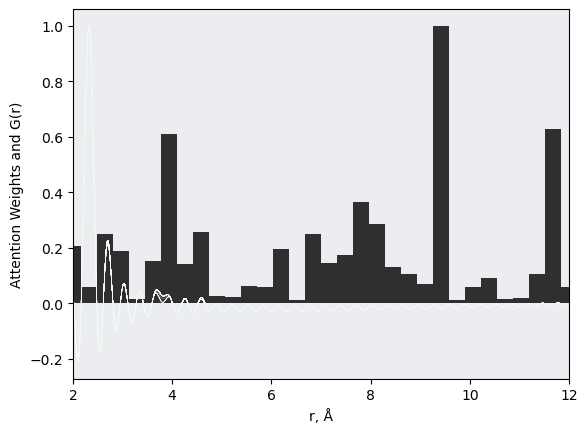

In [15]:
# Plotting of attention weights together with the first 300 PDFs of the dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import get_cmap

min_val = np.min(labels)
max_val = np.max(labels)
normalized_labels = (labels - min_val) / (max_val - min_val)
colormap = get_cmap('Greens')  # Using Greens for CeO2

# Get attention dimension directly from the weights array
attention_dim = len(summed_attention_weights)
print(f'Attention dimension: {attention_dim}')

# Map attention weights to the r-range (2-12 Å)
attention_r = np.linspace(2, 12, attention_dim)

fig, ax = plt.subplots()
for i in range(1, 300):
    color = colormap(normalized_labels[i])
    # PDF x-axis: 1000 points mapped to 2-12 Å
    pdf_r = np.arange(len(data_points[i, :])) / 100 + 2
    plt.plot(pdf_r, data_points[i, :] / data_points[i, :].max(), 
             alpha=0.7, linewidth=0.3, color=color)

ax.bar(attention_r, summed_attention_weights / summed_attention_weights.max(), 
       width=(10.0 / attention_dim), color='black', alpha=0.8)
ax.set_facecolor('#ebedf0')
plt.xlabel('r, Å')
plt.ylabel('Attention Weights and G(r)')
ax.set_xlim(2, 12)
plt.show()

6


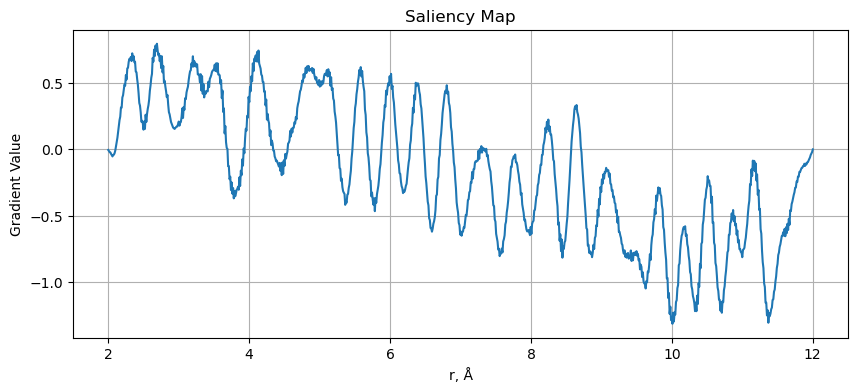

In [16]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load pre-trained model
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    model = keras.models.load_model(retrain_model_path)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

sample_index = 1  
sample_label = y_train[sample_index]
some_input = tf.convert_to_tensor(X_train[sample_index].reshape(1, 1000, 1), dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(some_input)
    prediction = model(some_input)
    loss = prediction[0][sample_label]

grad_values = tape.gradient(loss, some_input)
grad_numpy = grad_values.numpy().reshape(1000)
print(y_train[sample_index])
angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100

# Plot
plt.figure(figsize=(10, 4))
plt.plot(angstrom_range, grad_numpy)
plt.title('Saliency Map')
plt.xlabel('r, Å')
plt.ylabel('Gradient Value')
plt.grid(True)
plt.show()

Saliency maps saved to: /workspace/home/pdf-nn-data/results/q0.3-20/ceo2_clusters/figures/ceo2_saliency_maps_q0.3-20.png


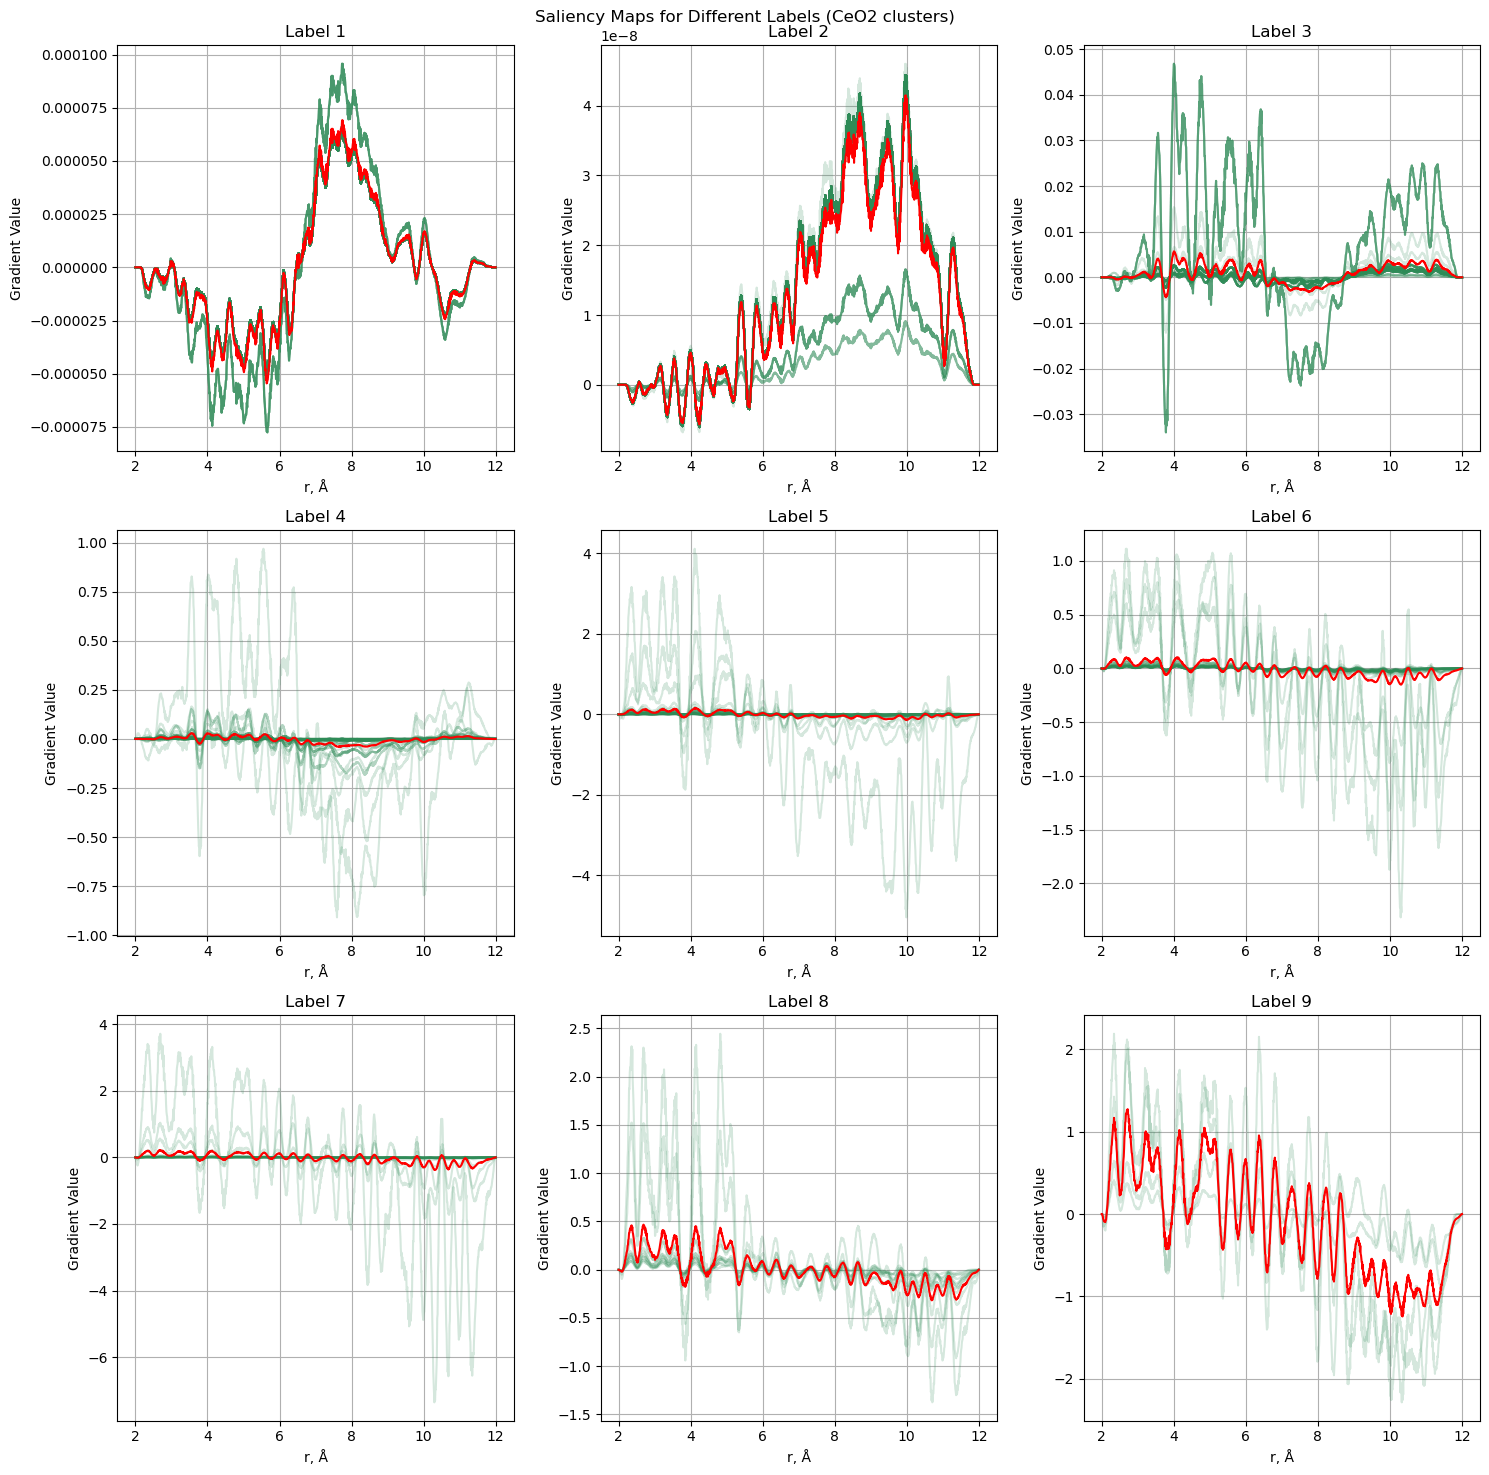

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sample_size = 500
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Saliency Maps for Different Labels (CeO2 clusters)')

# Loop through the unique labels (from 1 to 9)
for label in range(1, 10):
    ax = axes[(label - 1) // 3, (label - 1) % 3]
    gradients = []
    
    # Loop through first `sample_size` samples to check for this label
    for idx in range(min(sample_size, len(y_train))):
        if y_train[idx] == label:
            sample_input = tf.convert_to_tensor(X_train[idx].reshape(1, 1000, 1), dtype=tf.float32)
            
            with tf.GradientTape() as tape:
                tape.watch(sample_input)
                prediction = model(sample_input)
                loss = prediction[0][label - 1]  # Adjust for 0-based index
            
            grad_values = tape.gradient(loss, sample_input)
            grad_numpy = grad_values.numpy().reshape(1000)
            gradients.append(grad_numpy)
            
            angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100
            ax.plot(angstrom_range, grad_numpy, alpha=0.2, color='seagreen')
    
    # Plot the average line if we have any gradients for this label
    if gradients:
        mean_gradient = np.mean(gradients, axis=0)
        ax.plot(angstrom_range, mean_gradient, color='red')
    
    ax.set_title(f'Label {label}')
    ax.set_xlabel('r, Å')
    ax.set_ylabel('Gradient Value')
    ax.grid(True)

plt.tight_layout()
saliency_path = figures_dir / f'ceo2_saliency_maps_{TAG}.png'
plt.savefig(saliency_path, dpi=400)
print(f'Saliency maps saved to: {saliency_path}')
plt.show()